# **𝐋𝐨𝐠𝐢𝐬𝐭𝐢𝐜 𝐑𝐞𝐠𝐫𝐞𝐬𝐬𝐢𝐨𝐧**

It’s a supervised supervised machine learning algorithm used to predict probabilities and classify data into binary outcomes (like 0 or 1, Yes or No)

##**Analogy:**

Think of a school gate security checking IDs.

* The guard looks at information (ID card, uniform, name) → features

* Based on past records, the guard estimates: “How likely is this person a student?” → probability

* If the chance is high enough, the gate opens (Yes / 1)

* If not, the gate stays closed (No / 0)

So, Logistic Regression doesn’t just guess blindly — it calculates a probability first, then uses a cutoff (like 50%) to make a clear yes-or-no decision.

## **𝐇𝐨𝐰 𝐢𝐭 𝐰𝐨𝐫𝐤𝐬**

It starts like Linear Regression, where the model adds and multiplies inputs to get a score.
But instead of giving any number, it sends that score through a sigmoid function, which squeezes the result between 0 and 1.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df_log = pd.read_csv('/content/drive/MyDrive/Datasets/logistic regression/diabetes.csv')

In [ ]:
df_log.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df_log.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df_log.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**key observation**

Zero values are likely placeholders for missing data and should be handled.  

In [ ]:
(df_log == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


# **Understanding Zeros and Missing Values in the Dataset**

**Pregnancies**

Some records have a value of 0 for pregnancies. This is completely valid, because some individuals may never have been pregnant, especially younger women.
So, in this case, 0 does not mean missing data it is a real and meaningful value.

**Outcome**

The Outcome column shows whether a person has diabetes or not.

* 0 = Non-diabetic

* 1 = Diabetic

About 500 records have a value of 0, which simply means many individuals in the dataset do not have diabetes. This is expected and valid data.

**Why We Replace Some Zeros with NaN (Missing Values)**

In many medical datasets, a value of 0 is sometimes used to represent missing or unrecorded data, even when zero is not medically possible.

**Example:**

* Glucose = 0 is not realistic because a living person cannot have a glucose level of zero.

In such cases, we replace 0 with NaN (Not a Number) to clearly mark the value as missing.

## **Why This Is Important**

Replacing invalid zeros with NaN helps because:

* Missing values do not distort averages or statistics

* They can be handled properly during data cleaning

* Pandas and scikit-learn automatically recognize NaN as missing

This allows us to use tools like:

* `.isna()` or `.fillna()`

* `.dropna()`

## **What Happens If We Don’t Replace Zeros?**

If we leave invalid zeros in the data:

* Python will treat them as real values

* Statistics like mean and median become incorrect

* Machine learning models learn wrong patterns

So, replacing invalid zeros with NaN helps ensure accurate analysis and reliable models.

In [ ]:
# List of columns where zero is physiologically invalid
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_log[invalid_zero_cols] = df_log[invalid_zero_cols].replace(0, np.nan)

**`.replace(0, np.nan)`**

The command `.replace(0, np.nan)` changes every value that is 0 in the selected columns into np.nan.

np.nan means “Not a Number”, and it is the standard way pandas represents missing data.

In simple terms:

* 0 → treated as a real number

* np.nan → treated as missing data

In [ ]:
df_log.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [ ]:
df_log.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


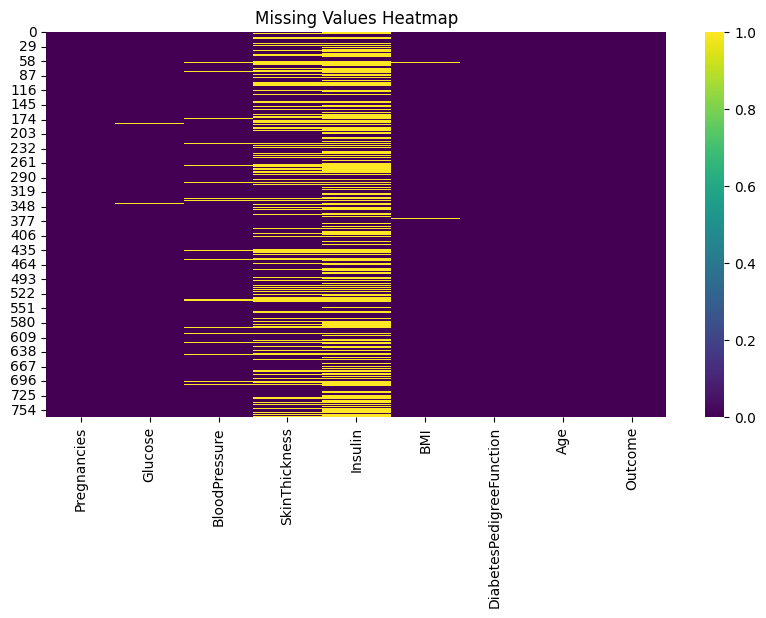

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(df_log.isnull(), cmap='viridis') #cbar=False
plt.title('Missing Values Heatmap')
plt.show()

**Heatmap**

A heatmap is a powerful data visualization tool that uses color gradients to represent the magnitude of values in a matrix or table.

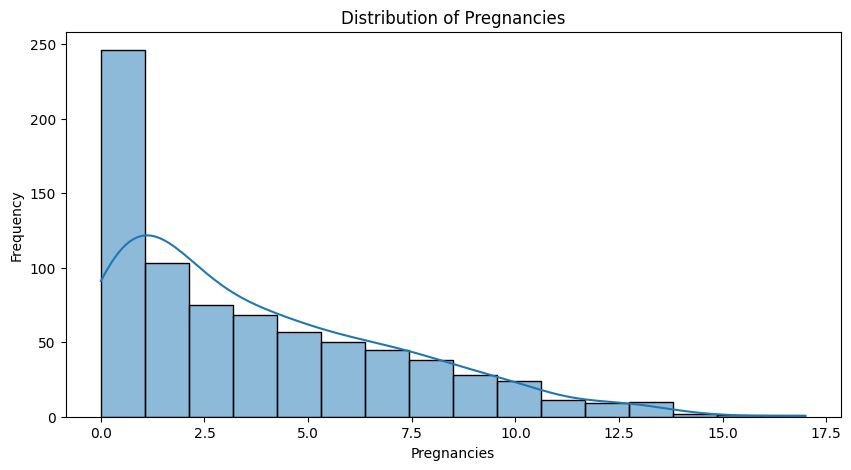

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_log, x='Pregnancies', kde=True)
plt.title('Distribution of Pregnancies')
plt.xlabel('Pregnancies')
plt.ylabel('Frequency')
plt.show()


The data for Pregnancies is skewed to the right, meaning most values are low, and there are fewer high values.

* The highest number of people fall in the 0–1 pregnancies range.

* This shows that many individuals in the dataset have had few or no pregnancies.

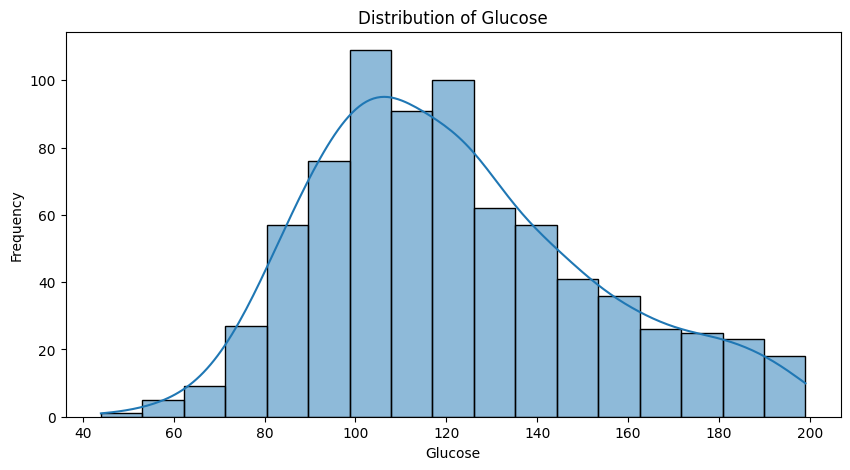

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_log, x='Glucose', kde=True)
plt.title('Distribution of Glucose')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.show()

The Glucose values are mostly centered around a typical range, making the distribution look close to normal.

However, there is a tail stretching to the right, which means a small number of individuals have much higher glucose levels than the rest.

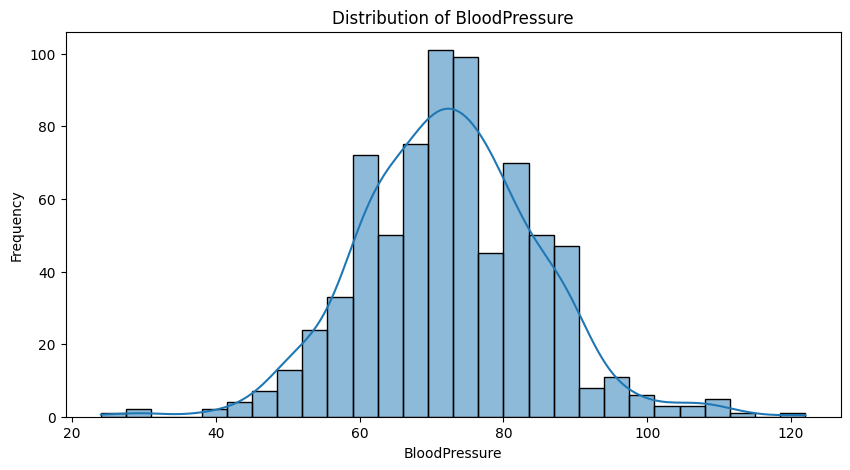

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_log, x='BloodPressure', kde=True)
plt.title('Distribution of BloodPressure')
plt.xlabel('BloodPressure')
plt.ylabel('Frequency')
plt.show()

The BloodPressure values form a distribution that is roughly normal, with most readings clustered around 70–90 mmHg.

Since normal blood pressure is usually around 80 mmHg or lower, this suggests that the dataset mostly contains healthy or commonly observed blood pressure levels.

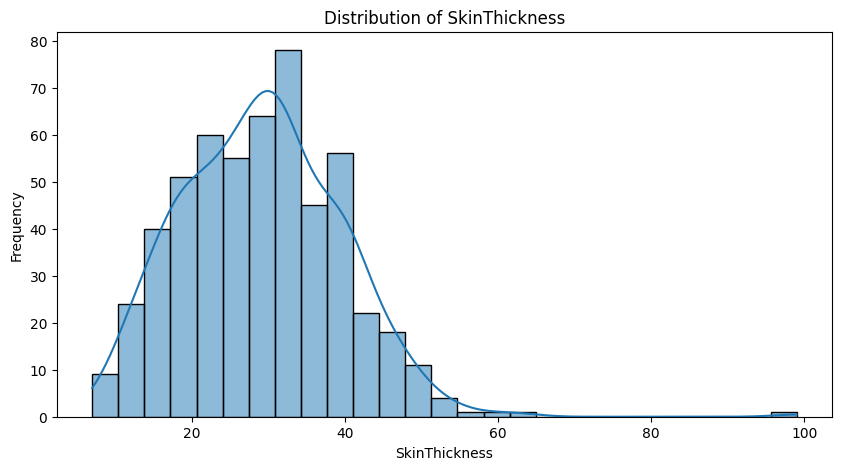

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_log, x='SkinThickness', kde=True)
plt.title('Distribution of SkinThickness')
plt.xlabel('SkinThickness')
plt.ylabel('Frequency')
plt.show()

The SkinThickness data is skewed to the right, meaning most values are on the lower end, with fewer high values.

* The highest concentration of values is around 20–30 mm.

* This shows that many individuals have relatively low skin thickness measurements, while only a few have much higher values.

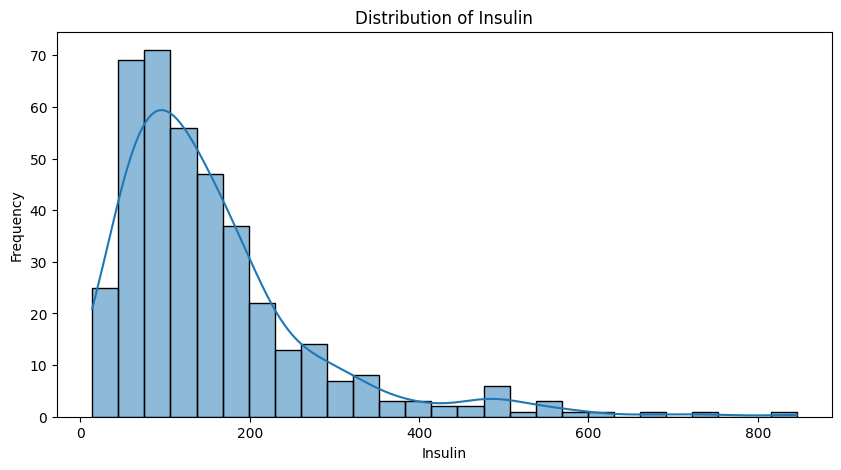

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_log, x='Insulin', kde=True)
plt.title('Distribution of Insulin')
plt.xlabel('Insulin')
plt.ylabel('Frequency')
plt.show()

The Insulin values are strongly skewed to the right, meaning most values are very low, while a small number are very high.

* Many individuals have insulin levels near the lower end.

* A few individuals have extremely high insulin levels, creating a long tail.

This shows that insulin levels vary widely across people in the dataset.

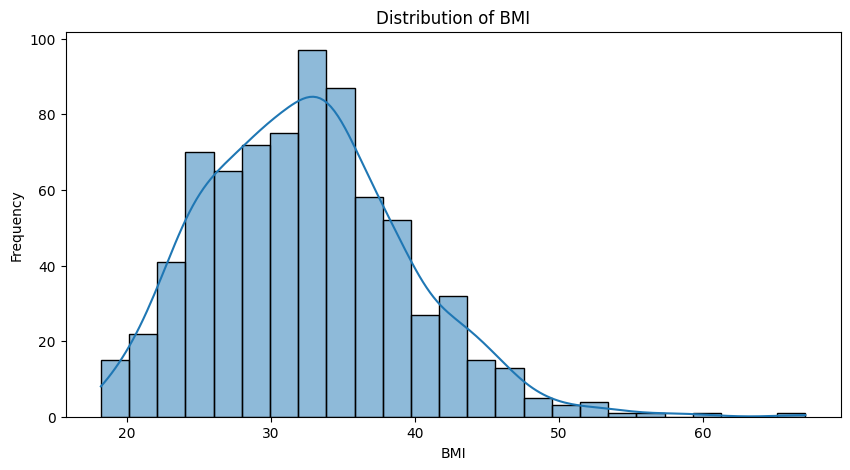

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_log, x='BMI', kde=True)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

The BMI distribution looks close to normal, but with a small right skew, meaning a few individuals have higher BMI values.

Most people fall within the healthy to overweight range, while fewer individuals are in the very high BMI range.

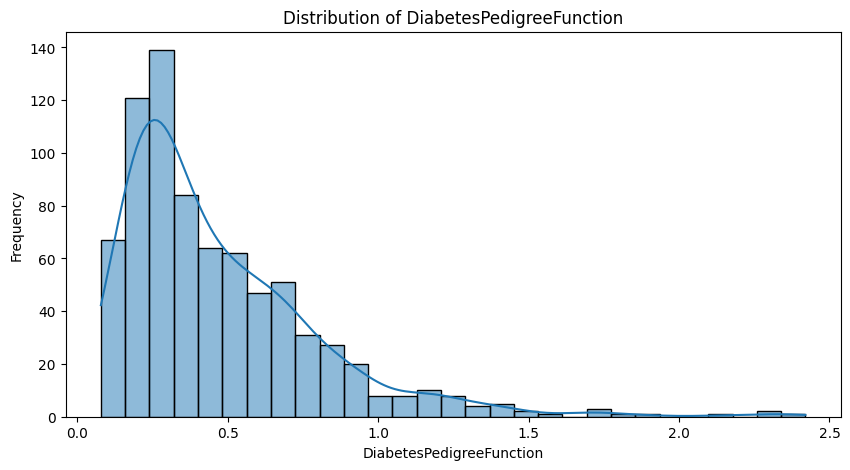

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_log, x='DiabetesPedigreeFunction', kde=True)
plt.title('Distribution of DiabetesPedigreeFunction')
plt.xlabel('DiabetesPedigreeFunction')
plt.ylabel('Frequency')
plt.show()

The DiabetesPedigreeFunction distribution is strongly skewed to the right, meaning most values are small, with only a few larger ones.

This suggests that most individuals in the dataset have a lower genetic risk of diabetes, while a smaller number have a higher inherited predisposition.

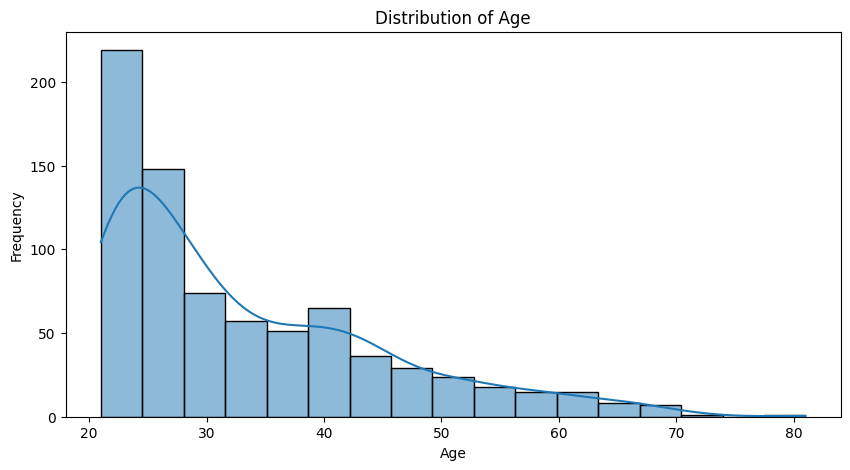

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_log, x='Age', kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The distribution is skewed to the right, with a peak in the younger adult age range (20s and 30s). There are fewer individuals in the older age groups.

## **Why Do We Fill In Missing Values**

Algorithms like Linear Regression, Logistic Regression, SVM, KNN, and Decision Trees in scikit-learn cannot process NaN values directly. You must handle them before modeling.

## **Common Imputation Strategies**

**1. Mean Imputation**

Replace missing values with the mean of the column

**2. Median Imputation**

Replace with the median (middle value).


**3. Mode Imputation**

Replace with the most frequent value.

Best for categorical features or discrete variables.

**4. Constant Value Imputation**

Replace with a fixed value like 0, -1, or "Unknown".


In [ ]:
# Columns with missing values
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Impute with the median of each column
df_log[cols_to_impute] = df_log[cols_to_impute].fillna(df_log[cols_to_impute].median())

df_log.isnull().sum()

In [ ]:
outcome_counts = df_log['Outcome'].value_counts()
print(outcome_counts)

Outcome
0    500
1    268
Name: count, dtype: int64


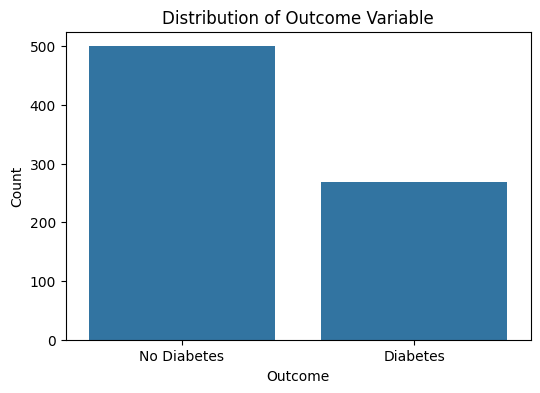

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_log, x='Outcome')
plt.title('Distribution of Outcome Variable')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Diabetes', 'Diabetes'])
plt.show()

The No Diabetes group has many more records than the Diabetes group.
This means the dataset is imbalanced, because one class appears much more often than the other.

**Why Class Imbalance Is a Problem**

* In machine learning, class imbalance can mislead the model.

* The model may learn to favor the majority class (No Diabetes).

* It could predict “No Diabetes” for almost everyone.

Even though accuracy may look high, the model would miss many real diabetes cases.

In [ ]:
X = df_log[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df_log['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**`stratify=y`**

It makes sure that both the training and test sets have the same proportion of each class as the original dataset.

In [ ]:
model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**`max_iter=1000**

The max_iter part stands for “maximum iterations.” It tells the tool how many times it should try to learn from the data to get the best predictions.

Setting max_iter=1000 means, “Keep trying up to 1,000 times to find the best answer.” It’s like telling a student to practice a math problem up to 1,000 times to get it right.

In [ ]:
y_train_pred = model_log.predict(X_train)
print(y_train_pred[:10])

[0 0 0 0 0 1 0 1 0 0]


In [ ]:
results_df = pd.DataFrame({'Actual': y_train, 'Predicted': y_train_pred})
print("Actual vs Predicted values:")
display(results_df.head(5))

Actual vs Predicted values:


,Actual,Predicted
353,0,0
711,0,0
373,0,0
46,0,0
682,0,0


In [ ]:
y_test_pred = model_log.predict(X_test)
print(y_test_pred[:10])

[1 0 0 0 0 0 0 1 0 1]


In [ ]:
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred})
print("Actual vs Predicted values:")
display(results_df.head())

Actual vs Predicted values:


,Actual,Predicted
44,0,1
672,0,0
700,0,0
630,1,0
81,0,0


In [ ]:
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': model_log.coef_[0]})
feature_importance = feature_importance.sort_values('Coefficient', ascending=False)
display(feature_importance)

,Feature,Coefficient
6,DiabetesPedigreeFunction,0.644358
0,Pregnancies,0.115651
5,BMI,0.103736
1,Glucose,0.040221
7,Age,0.012492
3,SkinThickness,0.002545
4,Insulin,-0.000939
2,BloodPressure,-0.004207


# **Model Evaluation - Accuracy**

## **Accuracy_score**

accuracy_score is a function from scikit-learn that measures how often a model’s predictions are correct.

In simple terms:

* It tells you "how many times the model got it right" out of the total number of predictions.


$$accuracy = (number of correct predictions) / (total number of predictions)$$


In [ ]:
# Accuracy on the training set
y_train_pred = model_log.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.7932


In [ ]:
# Accuracy on the testing set
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Testing Accuracy: {test_accuracy:.4f}")

Testing Accuracy: 0.7013


## **Accuracy Can Be Misleading in Imbalanced Datasets**

Accuracy only tells us how often the model is right overall.
But when one group is much smaller (like diabetics), we need better tools to know if the model is actually helpful

When dealing with imbalanced data, use metrics that focus on how well the model detects the minority class

# **Confusion Matrix**

A confusion matrix is a table that shows how well a classification model is performing.
It compares the predicted labels from the model with the actual labels in the data.

<img src="/content/drive/MyDrive/conf_matrix.png" alt="Confusion Matrix">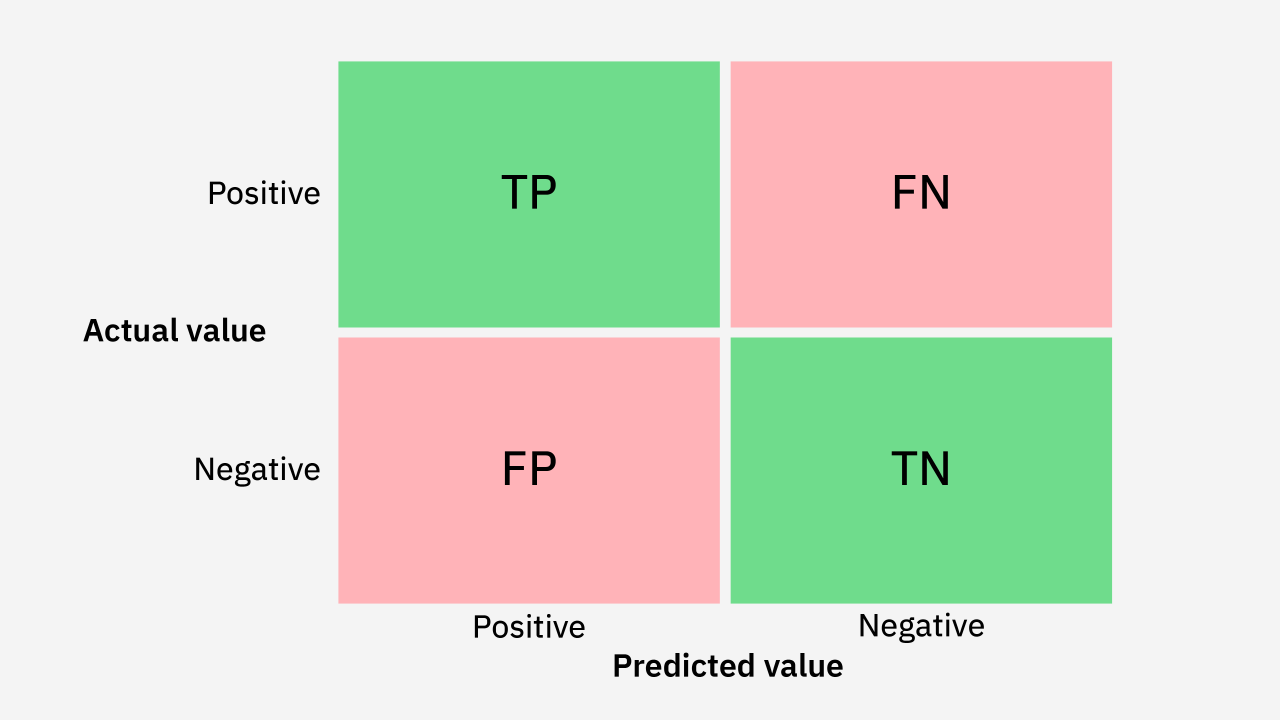

## **Confusion Matrix Terms**

**True Positive (TP)**

Model predicts YES, and the actual answer is YES

* Example: Model predicts a patient has diabetes, and they really do.

**False Negative (FN)**

Model predicts NO, but the actual answer is YES

* Example: Model says a patient doesn’t have diabetes, but they actually do.

**False Positive (FP)**

Model predicts YES, but the actual answer is NO

* Example: Model says a patient has diabetes, but they actually don’t.

**True Negative (TN)**

Model predicts NO, and the actual answer is NO

* Example: Model says a patient doesn’t have diabetes, and they truly don’t.

In [ ]:
# Confusion Matrix
print(f"\nConfusion Matrix (Test Set):")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)


Confusion Matrix (Test Set):
[[81 19]
 [27 27]]


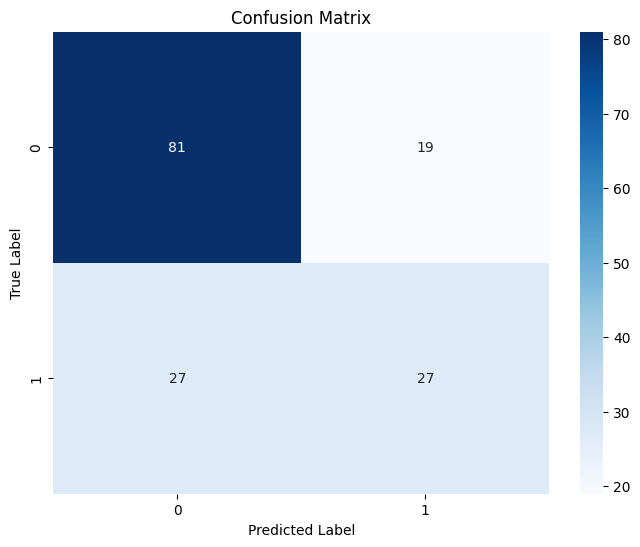

In [ ]:
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

| Column Name                  | Description                                                          |
| ---------------------------- | -------------------------------------------------------------------- |
| **Pregnancies**              | Number of times the patient has been pregnant                        |
| **Glucose**                  | Blood glucose level measured after a glucose tolerance test          |
| **BloodPressure**            | Diastolic blood pressure reading                                     |
| **SkinThickness**            | Thickness of the skin fold on the triceps, used to estimate body fat |
| **Insulin**                  | Insulin level in the blood measured after 2 hours                    |
| **BMI**                      | Body Mass Index, a measure of body fat based on height and weight    |
| **DiabetesPedigreeFunction** | Score representing genetic risk of diabetes based on family history  |
| **Age**                      | Age of the patient in years                                          |
| **Outcome**                  | Final diagnosis: **0 = No diabetes**, **1 = Diabetes**               |
